In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw/ai4i2020.csv")
df = pd.read_csv(data_path)

df.shape

(10000, 14)

In [3]:
feature_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

X = df[feature_columns].copy()

normal_X = X[df["Machine failure"] == 0].copy()

print("All readings:", X.shape)
print("Normal baseline readings:", normal_X.shape)

normal_X.describe().T

All readings: (10000, 5)
Normal baseline readings: (9661, 5)


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],9661.0,299.973999,1.990748,295.3,298.3,300.0,301.5,304.5
Process temperature [K],9661.0,309.995570,1.486846,305.7,308.8,310.0,311.1,313.8
Rotational speed [rpm],9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
Torque [Nm],9661.0,39.629655,9.472080,12.6,33.1,39.9,46.3,70.0
Tool wear [min],9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

normal_train, normal_test = train_test_split(
    normal_X,
    test_size=0.20,
    random_state=42,
)

scaler = StandardScaler()

normal_train_scaled = scaler.fit_transform(normal_train)
normal_test_scaled = scaler.transform(normal_test)

print("Normal training readings:", normal_train.shape)
print("Normal test readings:", normal_test.shape)

Normal training readings: (7728, 5)
Normal test readings: (1933, 5)


In [5]:
from sklearn.ensemble import IsolationForest

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    random_state=42,
    n_jobs=-1,
)

anomaly_model.fit(normal_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.035
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [6]:
X_scaled = scaler.transform(X)

df["anomaly_label"] = anomaly_model.predict(X_scaled)
df["anomaly_score"] = -anomaly_model.decision_function(X_scaled)
df["is_anomaly"] = df["anomaly_label"] == -1

df[["anomaly_score", "is_anomaly"]].head()

,anomaly_score,is_anomaly
0,-0.106329,False
1,-0.102395,False
2,-0.094943,False
3,-0.116581,False
4,-0.113739,False


In [7]:
from sklearn.metrics import precision_score, recall_score

y_true = df["Machine failure"]
anomaly_predictions = df["is_anomaly"].astype(int)

comparison = pd.crosstab(
    y_true,
    anomaly_predictions,
    rownames=["Actual failure"],
    colnames=["Flagged as anomaly"],
)

print(comparison)

print("Failure recall:", recall_score(y_true, anomaly_predictions))
print("Failure precision:", precision_score(y_true, anomaly_predictions))

Flagged as anomaly     0    1
Actual failure               
0                   9322  339
1                    259   80
Failure recall: 0.2359882005899705
Failure precision: 0.1909307875894988


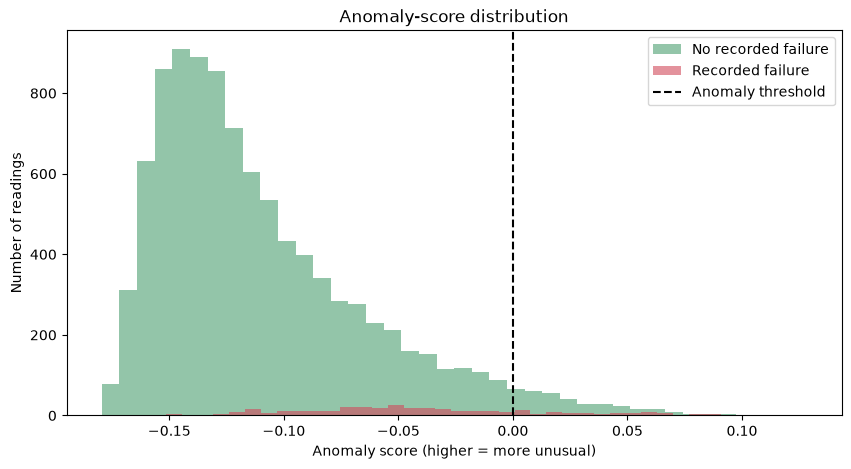

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for failure_value, label, color in [
    (0, "No recorded failure", "#4C9F70"),
    (1, "Recorded failure", "#D1495B"),
]:
    scores = df.loc[
        df["Machine failure"] == failure_value,
        "anomaly_score",
    ]
    plt.hist(
        scores,
        bins=40,
        alpha=0.6,
        label=label,
        color=color,
    )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="Anomaly threshold",
)

plt.title("Anomaly-score distribution")
plt.xlabel("Anomaly score (higher = more unusual)")
plt.ylabel("Number of readings")
plt.legend()
plt.show()

In [9]:
top_anomalies = (
    df[
        feature_columns
        + ["Machine failure", "anomaly_score", "is_anomaly"]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)

top_anomalies

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,anomaly_score,is_anomaly
5152,304.3,313.5,2643,12.7,21,0,0.128099,True
903,295.7,306.2,2270,14.6,149,1,0.125286,True
847,296.4,307.4,2833,5.6,213,1,0.115020,True
4988,303.8,313.1,2497,13.0,5,1,0.111309,True
5127,304.3,313.5,2245,15.1,172,0,0.106237,True
887,295.7,306.2,2161,16.5,105,0,0.103889,True
5186,304.0,313.0,2354,15.0,117,0,0.097011,True
4997,303.6,312.8,2659,11.4,26,1,0.096794,True
928,295.6,306.0,1949,21.9,5,0,0.096696,True
937,295.6,306.2,1263,61.8,27,0,0.093866,True


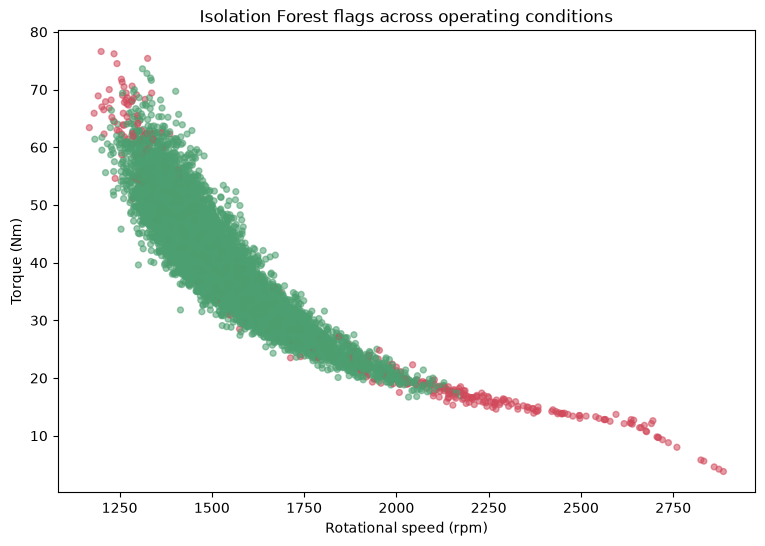

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Rotational speed [rpm]"],
    df["Torque [Nm]"],
    c=df["is_anomaly"].map({False: "#4C9F70", True: "#D1495B"}),
    alpha=0.55,
    s=18,
)

plt.xlabel("Rotational speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.title("Isolation Forest flags across operating conditions")
plt.show()

In [11]:
evaluation = pd.DataFrame(
    {
        "Metric": [
            "Readings flagged as anomalies",
            "Recorded failures found",
            "Recorded failures missed",
            "False alarms",
            "Failure recall",
            "Failure precision",
        ],
        "Value": [
            int(anomaly_predictions.sum()),
            int(((anomaly_predictions == 1) & (y_true == 1)).sum()),
            int(((anomaly_predictions == 0) & (y_true == 1)).sum()),
            int(((anomaly_predictions == 1) & (y_true == 0)).sum()),
            recall_score(y_true, anomaly_predictions),
            precision_score(y_true, anomaly_predictions),
        ],
    }
)

evaluation

,Metric,Value
0,Readings flagged as anomalies,419.000000
1,Recorded failures found,80.000000
2,Recorded failures missed,259.000000
3,False alarms,339.000000
4,Failure recall,0.235988
5,Failure precision,0.190931


In [12]:
evaluation_X = pd.concat(
    [
        normal_test,
        X[df["Machine failure"] == 1],
    ]
)

evaluation_y = df.loc[evaluation_X.index, "Machine failure"]

evaluation_predictions = (
    anomaly_model.predict(scaler.transform(evaluation_X)) == -1
).astype(int)

print("Failure recall:", recall_score(evaluation_y, evaluation_predictions))
print("Failure precision:", precision_score(evaluation_y, evaluation_predictions))

pd.crosstab(
    evaluation_y,
    evaluation_predictions,
    rownames=["Actual failure"],
    colnames=["Flagged anomaly"],
)

Failure recall: 0.2359882005899705
Failure precision: 0.5405405405405406


Flagged anomaly,0,1
Actual failure,,
0,1865,68
1,259,80


In [13]:
results = []

for contamination in [0.01, 0.02, 0.035, 0.05, 0.10]:
    candidate_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(normal_train_scaled)

    predictions = (
        candidate_model.predict(scaler.transform(evaluation_X)) == -1
    ).astype(int)

    results.append(
        {
            "Contamination": contamination,
            "Recall": recall_score(evaluation_y, predictions),
            "Precision": precision_score(evaluation_y, predictions),
            "False alarms": int(
                ((predictions == 1) & (evaluation_y == 0)).sum()
            ),
        }
    )

pd.DataFrame(results)

,Contamination,Recall,Precision,False alarms
0,0.010,0.120944,0.621212,25
1,0.020,0.174041,0.590000,41
2,0.035,0.235988,0.540541,68
3,0.050,0.294985,0.510204,96
4,0.100,0.460177,0.448276,192


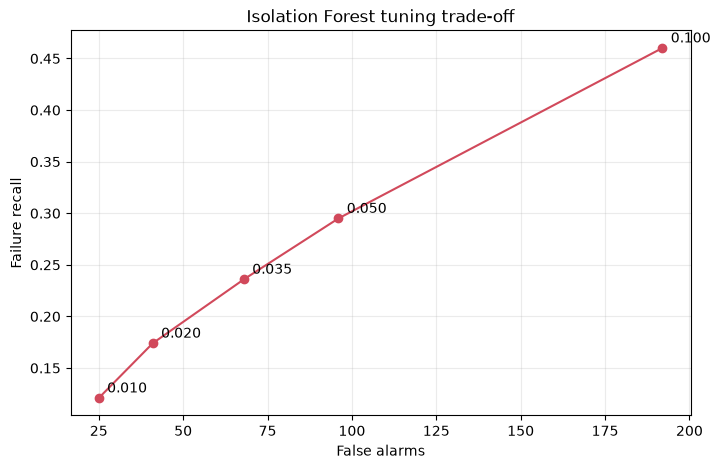

In [14]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.plot(
    results_df["False alarms"],
    results_df["Recall"],
    marker="o",
    color="#D1495B",
)

for _, row in results_df.iterrows():
    plt.annotate(
        f'{row["Contamination"]:.3f}',
        (row["False alarms"], row["Recall"]),
        xytext=(6, 4),
        textcoords="offset points",
    )

plt.xlabel("False alarms")
plt.ylabel("Failure recall")
plt.title("Isolation Forest tuning trade-off")
plt.grid(alpha=0.25)
plt.show()

In [15]:
final_anomaly_scaler = StandardScaler()
final_normal_scaled = final_anomaly_scaler.fit_transform(normal_X)

final_anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    random_state=42,
    n_jobs=-1,
)

final_anomaly_model.fit(final_normal_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.035
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [16]:
import joblib

anomaly_bundle = {
    "model": final_anomaly_model,
    "scaler": final_anomaly_scaler,
    "feature_names": feature_columns,
    "contamination": 0.035,
    "model_name": "Isolation Forest healthy-baseline v1",
}

anomaly_model_path = Path("../models/isolation_forest_anomaly_model.joblib")
joblib.dump(anomaly_bundle, anomaly_model_path)

print(f"Saved model to: {anomaly_model_path.resolve()}")

Saved model to: D:\Stuff\Coding\SentinelAI\models\isolation_forest_anomaly_model.joblib


In [17]:
loaded_bundle = joblib.load(anomaly_model_path)

sample_reading = df.loc[
    [df["anomaly_score"].idxmax()],
    loaded_bundle["feature_names"],
]

sample_scaled = loaded_bundle["scaler"].transform(sample_reading)

sample_is_anomaly = (
    loaded_bundle["model"].predict(sample_scaled)[0] == -1
)

sample_score = -loaded_bundle["model"].decision_function(sample_scaled)[0]

print("Anomaly score:", round(sample_score, 4))
print("Flagged as anomaly:", sample_is_anomaly)

Anomaly score: 0.1245
Flagged as anomaly: True
